<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Hyperparameters ────────────────────────────────────────
SEED        = 42
SEQ_LEN     = 10
HIDDEN_SIZE = 16
N_LAYERS    = 2
DROPOUT     = 0.4
BATCH_SIZE  = 256
EPOCHS      = 30
LR          = 3e-4
PATIENCE    = 6

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Load processed data from CSV ───────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Load the full dataset for the main experiment
save_df = pd.read_csv("/content/drive/MyDrive/lob_full.csv")

split_idx = int((save_df['split'] == 'train').sum())

# CRITICAL: Exclude future_return from input features X_all to prevent data leakage!
X_all = save_df.drop(columns=['label', 'split', 'future_return']).values.astype(np.float32)
y_all = (save_df['label'].values + 1).astype(np.int64)   # {-1,0,1} -> {0,1,2}

# Extract all future_returns and store them for the final backtesting phase
returns_all = save_df['future_return'].values

print(f"X shape     : {X_all.shape}")
print(f"y shape     : {y_all.shape}")
print(f"n_features  : {X_all.shape[1]}")


Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape     : (99901, 45)
y shape     : (99901,)
n_features  : 45


Device: cuda
Mounted at /content/drive
X shape     : (99901, 45)
y shape     : (99901,)
n_features  : 45
Train samples : 79,911
Test  samples : 19,962
Class weights (Down/Flat/Up): [1.48  0.603 1.499]
Model        : Bidirectional LSTM
Input features: 45
Trainable params: 12,131
LOBLSTM(
  (input_proj): Linear(in_features=45, out_features=16, bias=True)
  (lstm): LSTM(16, 16, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=16, out_features=3, bias=True)
  )
)
  Training Bidirectional LSTM
Ep   1/30 | Train Loss 0.5520 | Val Loss 0.4306 | Val Acc 0.2734
Ep   2/30 | Train Loss 0.4950 | Val Loss 0.4158 | Val Acc 0.2828
Ep   3/30 | Train Loss 0.4810 | Val Loss 0.4085 | Val Acc 0.2855
Ep   4/30 | Train Loss 0.4744 | Val Loss 0.4035 |

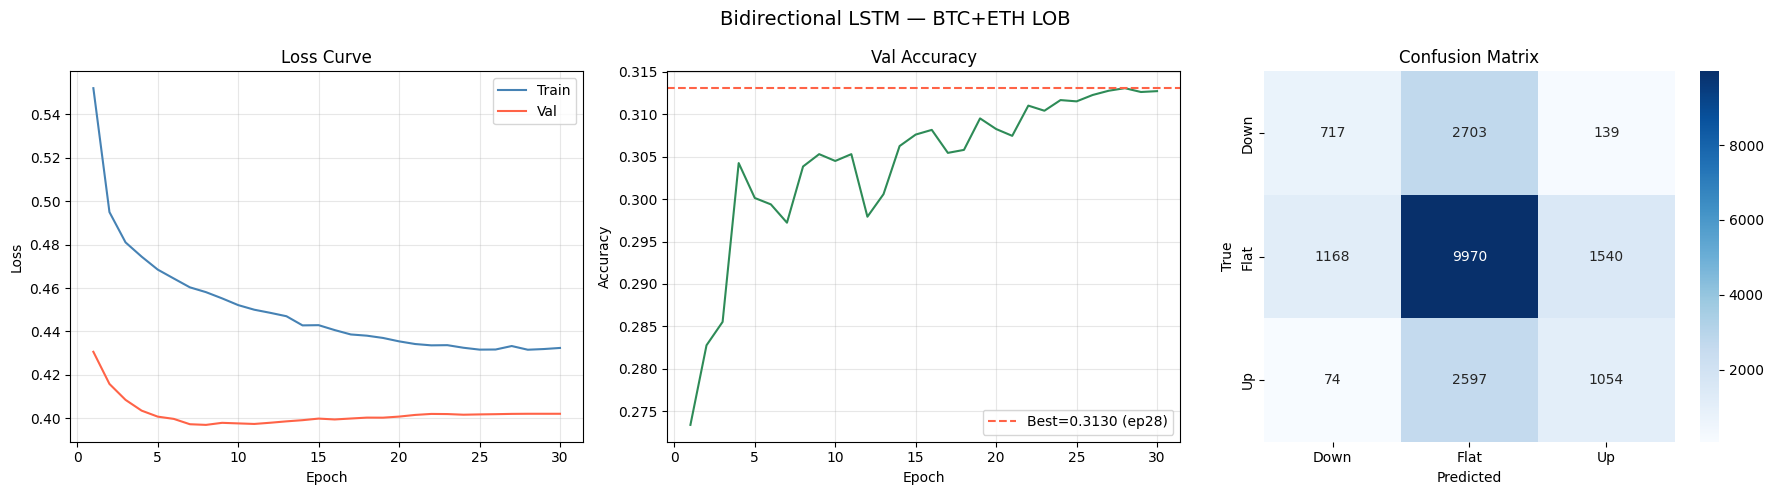

In [1]:
# ── Dataset ────────────────────────────────────────────────
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]


# ── DataLoaders ────────────────────────────────────────────
def build_loaders(X, y, split):
    """Chronological split -> normalise (fit on train) -> sliding-window DataLoaders."""

    embargo_gap = 10

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X[:split])

    X_te   = scaler.transform(X[split + embargo_gap :])
    y_tr, y_te = y[:split], y[split + embargo_gap :]

    counts  = np.bincount(y_tr, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print(f"Train samples : {len(train_loader.dataset):,}")
    print(f"Test  samples : {len(test_loader.dataset):,}")
    print(f"Class weights (Down/Flat/Up): {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w, scaler

train_loader, test_loader, class_w, scaler = build_loaders(X_all, y_all, split_idx)

import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ── Bidirectional LSTM ─────────────────────────────────────
class LOBLSTM(nn.Module):
    """
    Architecture
    ────────────
    Input (B, T, n_features)
      -> Linear projection  (n_features -> HIDDEN_SIZE)
      -> Bidirectional LSTM x N_LAYERS
      -> Concat last forward + backward hidden state  (2 * HIDDEN_SIZE)
      -> LayerNorm
      -> Classification head -> 3 classes (Down / Flat / Up)
    """

    def __init__(self, n_features: int):
        super().__init__()
        self.input_proj = nn.Linear(n_features, HIDDEN_SIZE)
        self.lstm = nn.LSTM(
            input_size    = HIDDEN_SIZE,
            hidden_size   = HIDDEN_SIZE,
            num_layers    = N_LAYERS,
            batch_first   = True,
            bidirectional = True,
            dropout       = DROPOUT if N_LAYERS > 1 else 0.0,
        )

        self.norm = nn.LayerNorm(HIDDEN_SIZE* 2)
        self.head = nn.Sequential(
            nn.Linear(HIDDEN_SIZE* 2, HIDDEN_SIZE),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_SIZE, 3),
        )
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n // 4 : n // 2].fill_(1)   # forget-gate bias = 1
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_proj(x)              # (B, T, HIDDEN_SIZE)
        _, (h_n, _) = self.lstm(x)          # h_n: (N_LAYERS, B, HIDDEN_SIZE)

        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat((h_forward, h_backward), dim=1) # (B, 2 * HIDDEN_SIZE)
        h = self.norm(h)
        return self.head(h)


n_features = X_all.shape[1]
model      = LOBLSTM(n_features).to(DEVICE)
n_params   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model        : Bidirectional LSTM")
print(f"Input features: {n_features}")
print(f"Trainable params: {n_params:,}")
print(model)

# ── Training loop ──────────────────────────────────────────
criterion = FocalLoss(alpha=class_w, gamma=2.0, reduction='mean')
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc, best_state, patience_cnt = 0.0, None, 0

print("=" * 60)
print("  Training Bidirectional LSTM")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    # ── train ──
    model.train(); running = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(yb)
    scheduler.step()
    train_loss = running / len(train_loader.dataset)

    # ── validate ──
    model.eval(); vloss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(Xb)
            vloss  += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total   += len(yb)
    val_loss = vloss / total
    val_acc  = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Ep {epoch:3d}/{EPOCHS} | Train Loss {train_loss:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc, patience_cnt = val_acc, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
            break

model.load_state_dict(best_state)
print(f"\nBest Val Accuracy: {best_acc:.4f}")

# ── Evaluation ─────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []
CONFIDENCE_THRESHOLD = 0.55

with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(DEVICE))

        probs = torch.softmax(logits, dim=1)

        preds = torch.ones(len(yb), dtype=torch.long, device=DEVICE)

        preds[probs[:, 0] > CONFIDENCE_THRESHOLD] = 0
        preds[probs[:, 2] > CONFIDENCE_THRESHOLD] = 2

        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

print("=" * 60)
print("  Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"]))

# ── Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Bidirectional LSTM — BTC+ETH LOB", fontsize=14)

ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], label="Train", color="steelblue")
axes[0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

best_ep = int(np.argmax(history["val_acc"])) + 1
axes[1].plot(ep, history["val_acc"], color="seagreen")
axes[1].axhline(best_acc, color="tomato", linestyle="--", label=f"Best={best_acc:.4f} (ep{best_ep})")
axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Down","Flat","Up"],
            yticklabels=["Down","Flat","Up"])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()



  OOS Strategy Backtest Report (Net of Fees & Slippage)
Assumed Fee Rate     : 5.0 bps
Total Net Return     : -30.43%
Annualized Sharpe    : -162.75
Max Drawdown         : -30.39%
Total Trades         : 2036


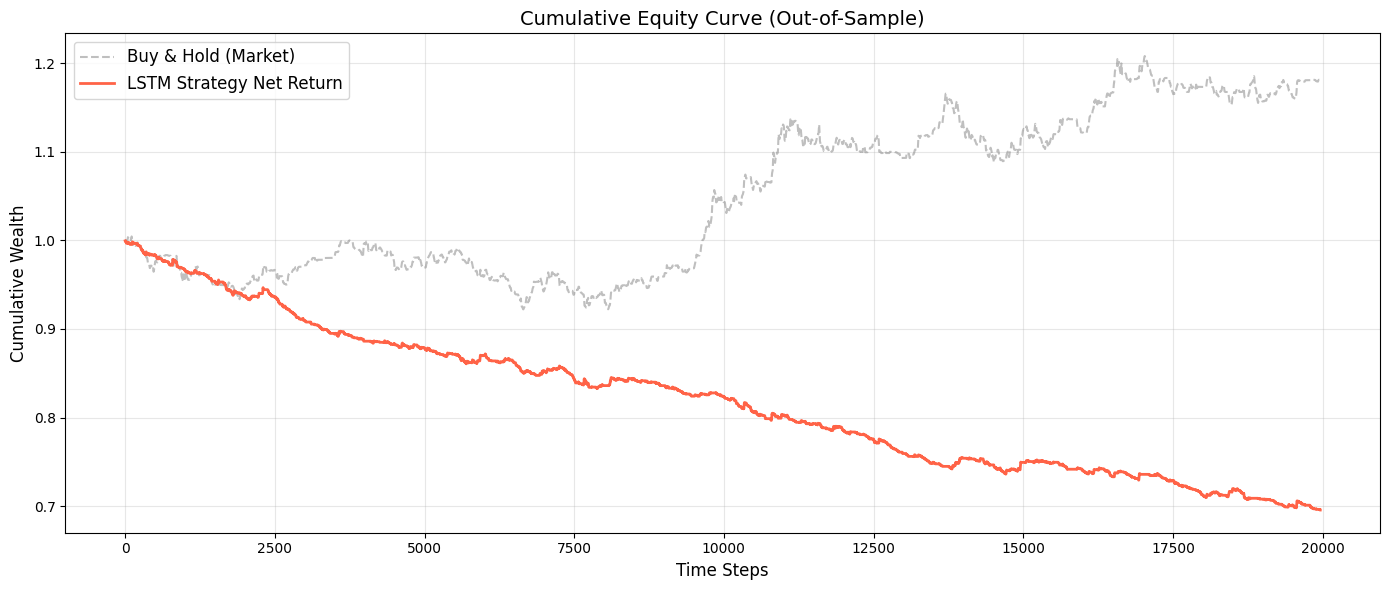

In [2]:
# Calculate the true starting index of the test set in the global data
# Offset = train length + embargo gap + (sequence window length - 1)
embargo_gap = 10
start_idx = split_idx + embargo_gap + SEQ_LEN - 1

# Extract the true future returns matching the length of y_pred
test_returns = returns_all[start_idx : start_idx + len(y_pred)]

# Ensure dimensional alignment to prevent errors
assert len(test_returns) == len(y_pred), f"Length mismatch: returns({len(test_returns)}) vs preds({len(y_pred)})"


def run_vectorized_backtest(y_pred, future_returns, fee_rate=0.0005):
    """
    Vectorized strategy backtesting engine
    """
    # 1. Signal mapping (0: Down, 1: Flat, 2: Up) -> (-1: Short, 0: Flat, 1: Long)
    positions = y_pred - 1

    # 2. Calculate raw strategy returns
    raw_returns = positions * future_returns

    # 3. Calculate turnover and transaction costs
    # Logic: Transaction costs are incurred only when the position changes
    position_change = np.zeros_like(positions)
    position_change[1:] = np.abs(positions[1:] - positions[:-1])
    position_change[0] = np.abs(positions[0]) # Cost of the initial position

    costs = position_change * fee_rate
    net_returns = raw_returns - costs

    # 4. Calculate Cumulative Wealth
    cum_returns = np.cumprod(1 + net_returns)
    market_cum_returns = np.cumprod(1 + future_returns) # Buy and hold benchmark

    # 5. Core performance metrics calculation
    total_return = cum_returns[-1] - 1

    # Assuming data is in 10-second steps, 1 year = 3,153,600 steps (365*24*60*6)
    # Modify this annualization factor if using a different frequency
    annual_factor = 3153600
    annualized_vol = np.std(net_returns) * np.sqrt(annual_factor)
    annualized_ret = np.mean(net_returns) * annual_factor
    sharpe_ratio = annualized_ret / annualized_vol if annualized_vol > 0 else 0

    # Max Drawdown
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = np.min(drawdown)

    # 6. Print report
    print("=" * 60)
    print("  OOS Strategy Backtest Report (Net of Fees & Slippage)")
    print("=" * 60)
    print(f"Assumed Fee Rate     : {fee_rate * 10000:.1f} bps")
    print(f"Total Net Return     : {total_return * 100:.2f}%")
    print(f"Annualized Sharpe    : {sharpe_ratio:.2f}")
    print(f"Max Drawdown         : {max_drawdown * 100:.2f}%")
    print(f"Total Trades         : {np.sum(position_change > 0)}")

    # 7. Plot equity curve
    plt.figure(figsize=(14, 6))
    plt.plot(market_cum_returns, label="Buy & Hold (Market)", color="gray", alpha=0.5, linestyle="--")
    plt.plot(cum_returns, label="LSTM Strategy Net Return", color="tomato", linewidth=2)
    plt.title("Cumulative Equity Curve (Out-of-Sample)", fontsize=14)
    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Cumulative Wealth", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return net_returns, cum_returns

# Pass your predictions and extracted test returns
net_ret, cum_ret = run_vectorized_backtest(y_pred, test_returns, fee_rate=0.0005)